<a href="https://colab.research.google.com/github/IamAshishSeth/ideal-guacamole/blob/main/Business_Case_Netflix_Data_Exploration_and_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Data Exploration and Visualization

## Problem Statement

Netflix is one of the world's leading streaming platforms, offering a large collection of movies and TV shows across multiple countries and genres. The objective of this analysis is to explore the Netflix dataset, identify patterns in content production and distribution, and generate actionable business insights. The findings will help understand what type of content Netflix should focus on producing and how it can continue to grow its business globally.

## Import Libraries

The required Python libraries are imported for data manipulation, numerical computation, and data visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

The Netflix dataset was loaded into a Pandas DataFrame using the read_csv() function. The head() function was used to inspect the first five records and verify that the dataset was imported correctly.

In [ ]:
df = pd.read_csv('netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**Observation**

The dataset contains information about Netflix Movies and TV Shows, including attributes such as title, director, cast, country, release year, rating, duration, genre, and description. Missing values can already be observed in some columns such as director and cast.

## Dataset Shape

The shape of the dataset is examined to understand the number of records and attributes available for analysis.

In [ ]:
df.shape

(8807, 12)

**Observation**

The dataset contains 8,807 records and 12 attributes. Each record represents a Netflix title, either a Movie or a TV Show.

## Dataset Information

The structure of the dataset is examined to understand the available attributes, data types, and missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


**Observation**

The dataset contains 12 attributes, of which 11 are categorical/text-based (object) and 1 is numerical (release_year).

Missing values are present in several columns, particularly director, cast, country, date_added, rating, and duration. The director column contains the highest number of missing values. These missing values will need to be handled during the data preprocessing stage before performing detailed analysis.

## Missing Value Analysis

The number of missing values in each column is examined to identify data quality issues that may affect the analysis.

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


**Observation**

Missing values are present in six columns. The director column contains the highest number of missing values (2,634), followed by country (831) and cast (825). The date_added, rating, and duration columns contain only a small number of missing values.

The remaining columns do not contain any missing values and can be used directly for further analysis.

## Handling Missing Values

Missing values are replaced to ensure consistency and prevent errors during analysis. As per the case study guidelines, categorical variables with missing values are updated with appropriate "Unknown" labels.

In [ ]:
df.fillna({
    'director': 'Unknown Director',
    'cast': 'Unknown Actor',
    'country': 'Unknown Country',
    'rating': 'Unknown Rating',
    'duration': 'Unknown Duration',
    'date_added': 'Unknown Date'
}, inplace=True)

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


**Observation**

According to the case study guidelines, missing values in categorical columns were replaced with meaningful placeholder values. No numerical columns contained missing values; therefore, no replacement with 0 was required.

## Unnesting Multi-Value Columns

Several columns contain multiple comma-separated values within a single cell. These columns are unnested to enable accurate analysis of countries, actors, directors, and genres.

In [ ]:
country_df = (
    df.assign(country=df['country'].str.split(','))
      .explode('country')
)

country_df['country'] = country_df['country'].str.strip()

country_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Actor,Unknown Country,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
director_df = (
    df.assign(director=df['director'].str.split(','))
      .explode('director')
)

director_df['director'] = director_df['director'].str.strip()

director_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Actor,Unknown Country,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
cast_df = (
    df.assign(cast=df['cast'].str.split(','))
      .explode('cast')
)

cast_df['cast'] = cast_df['cast'].str.strip()

cast_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown Director,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown Director,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown Director,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [ ]:
genre_df = (
    df.assign(listed_in=df['listed_in'].str.split(','))
      .explode('listed_in')
)

genre_df['listed_in'] = genre_df['listed_in'].str.strip()

genre_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,"September 24, 2021",2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...


**Observation**

The country, director, cast, and genre columns contained multiple comma-separated values within a single record. These columns were unnested into separate rows to enable accurate analysis of countries, actors, directors, and genres.

## Comparison of Movies and TV Shows

The distribution of Movies and TV Shows is examined to understand the composition of Netflix's content library.

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


**Observation**

Movies dominate Netflix's content library, accounting for 6,131 titles, while TV Shows account for 2,676 titles. This indicates that Netflix has historically focused more on Movies than TV Shows.

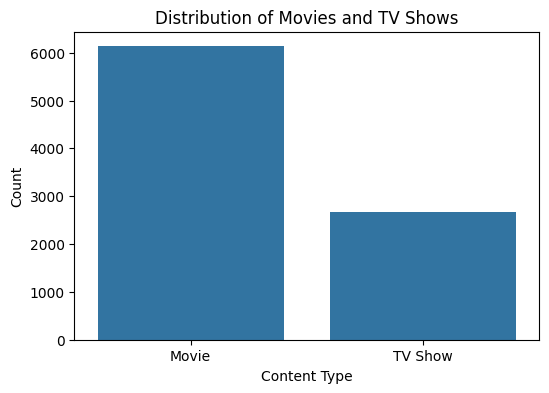

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='type')

plt.title('Distribution of Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

**Observation**

The visualization confirms that Movies significantly outnumber TV Shows on Netflix. Although Movies form the majority of the catalog, TV Shows still represent a substantial portion of the platform's content and may indicate an area of growing investment.

## Top 10 Countries Producing Movies

The number of Movies produced in each country is analyzed to identify the major contributors to Netflix's movie catalog.

In [ ]:
movie_country = (
    country_df[country_df['type'] == 'Movie']
    ['country']
    .value_counts()
    .head(10)
)

movie_country

,count
country,
United States,2752
India,962
United Kingdom,534
Unknown Country,440
Canada,319
France,303
Germany,182
Spain,171
Japan,119


**Observation**

The United States is the largest contributor to Netflix's movie catalog with 2,752 titles, significantly higher than any other country. India ranks second with 962 movies, followed by the United Kingdom with 534 movies. This indicates that Netflix's movie content is heavily concentrated in a few major production markets.

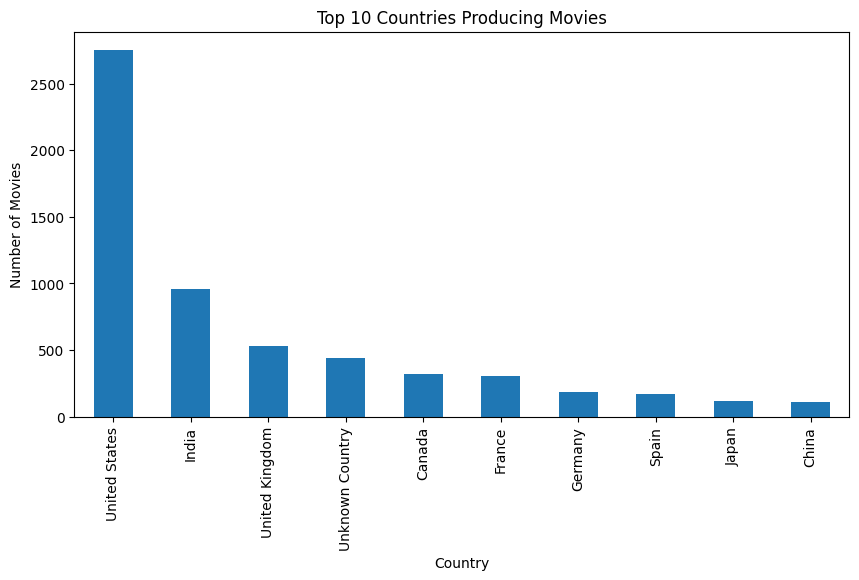

In [ ]:
plt.figure(figsize=(10,5))

movie_country.plot(kind='bar')

plt.title('Top 10 Countries Producing Movies')
plt.xlabel('Country')
plt.ylabel('Number of Movies')

plt.show()

**Observation**

The United States dominates movie production on Netflix, followed by India and the United Kingdom. The large gap between the United States and other countries suggests that Netflix's movie catalog relies heavily on American content, while India represents a significant international market.

## Top 10 Countries Producing TV Shows

The number of TV Shows produced in each country is analyzed to identify the major contributors to Netflix's TV Show catalog.

In [ ]:
tv_country = (
    country_df[
        (country_df['type'] == 'TV Show') &
        (country_df['country'] != 'Unknown Country')
    ]['country']
    .value_counts()
    .head(10)
)

tv_country

,count
country,
United States,938
United Kingdom,272
Japan,199
South Korea,170
Canada,126
France,90
India,84
Taiwan,70
Australia,66


**Observation**

The United States leads TV Show production on Netflix with 938 titles, followed by the United Kingdom with 272 titles. Japan (199) and South Korea (170) are among the top contributors, highlighting the growing importance of Asian content in Netflix's TV Show catalog. Unlike Movies, India contributes relatively fewer TV Shows compared to other leading countries.

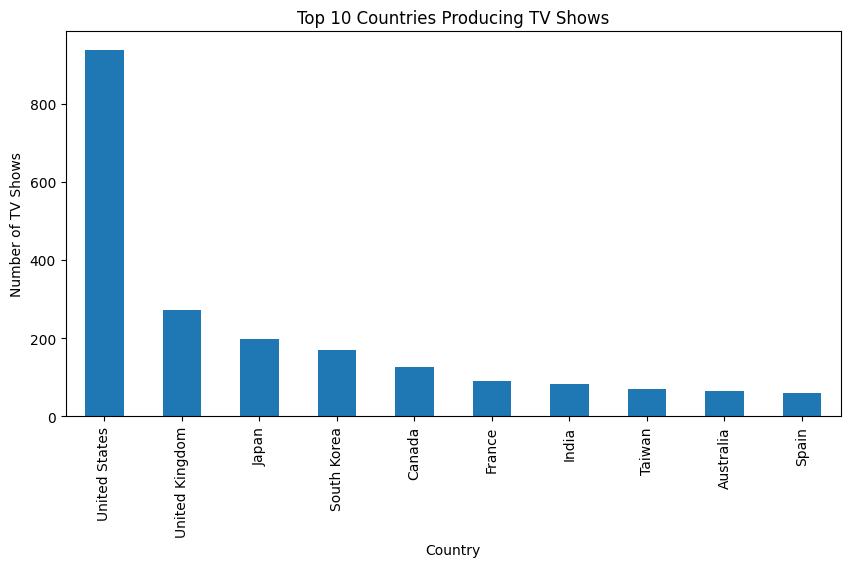

In [ ]:
plt.figure(figsize=(10,5))

tv_country.plot(kind='bar')

plt.title('Top 10 Countries Producing TV Shows')
plt.xlabel('Country')
plt.ylabel('Number of TV Shows')

plt.show()

**Observation**

The distribution of TV Show production is more diverse compared to Movies. While the United States remains the largest contributor, countries such as Japan and South Korea have established a strong presence in Netflix's TV Show library.

## Content Release Trend Over Time

The distribution of Movies and TV Shows across release years is analyzed to understand how Netflix's content portfolio has evolved over time.

In [ ]:
content_by_year = (
    df.groupby(['release_year', 'type'])
      .size()
      .reset_index(name='count')
)

content_by_year.head()

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


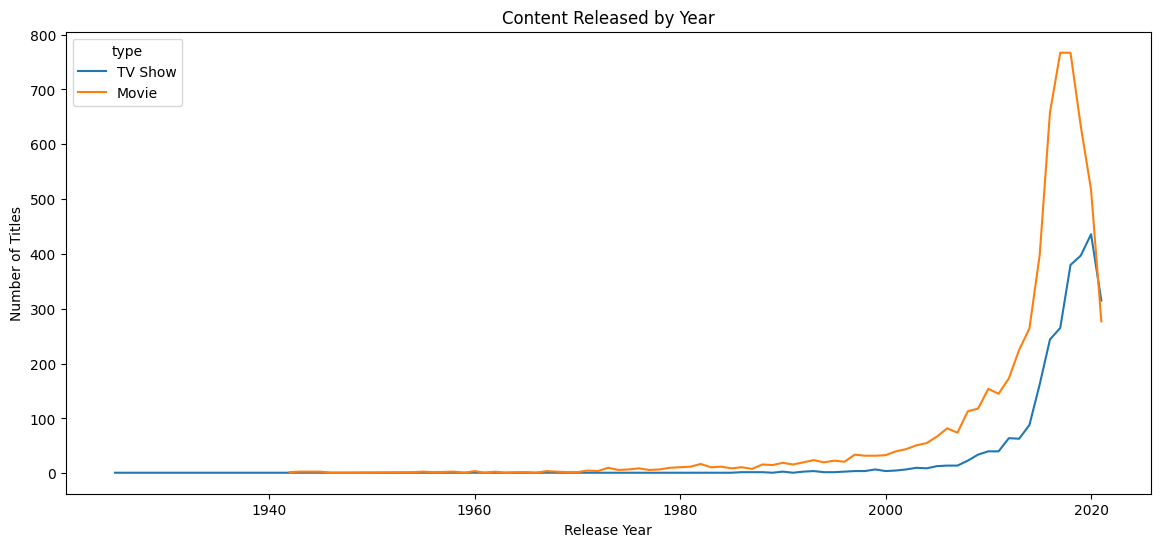

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=content_by_year,
    x='release_year',
    y='count',
    hue='type'
)

plt.title('Content Released by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

**Observation**

The number of Movies and TV Shows released remained relatively low until the early 2000s. From 2010 onwards, both content types experienced rapid growth, indicating a significant expansion of Netflix's content library.

Movies consistently outnumber TV Shows throughout the timeline. However, TV Shows experienced particularly strong growth after 2015, suggesting an increasing focus on serialized content. Both categories reached their peak around 2018–2020 before showing a decline in the most recent years.

Although Movies remain the dominant content type, the growth rate of TV Shows increased substantially after 2015, indicating a growing emphasis on TV content in recent years.

## Best Month to Launch Content

The month in which content was added to Netflix is analyzed to identify seasonal trends and determine the most active release periods.

In [ ]:
df['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce'
)

df['month_added'] = df['date_added'].dt.month_name()

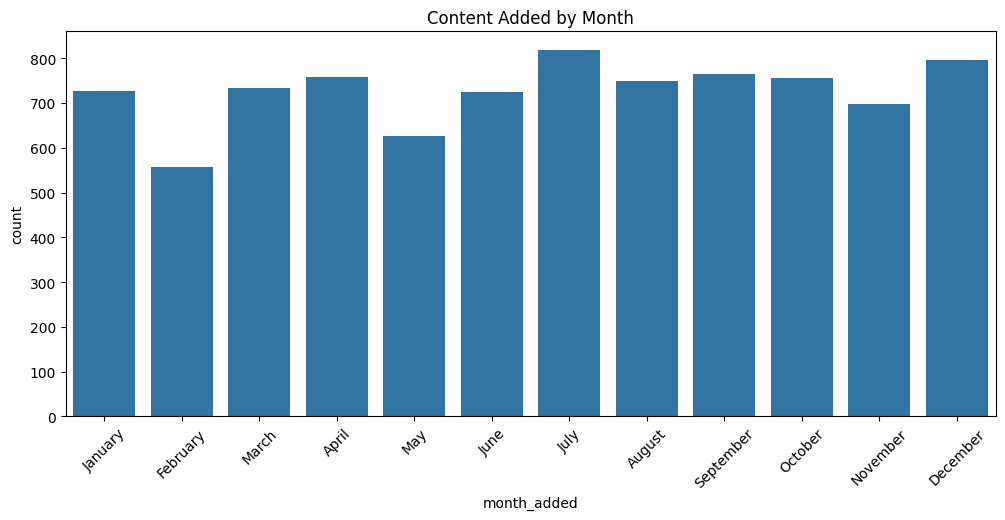

In [ ]:
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='month_added',
    order=month_order
)

plt.title('Content Added by Month')
plt.xticks(rotation=45)

plt.show()

In [ ]:
month_type = (
    df.groupby(['month_added', 'type'])
      .size()
      .reset_index(name='count')
)

month_type['month_added'] = pd.Categorical(
    month_type['month_added'],
    categories=month_order,
    ordered=True
)

month_type = month_type.sort_values('month_added')

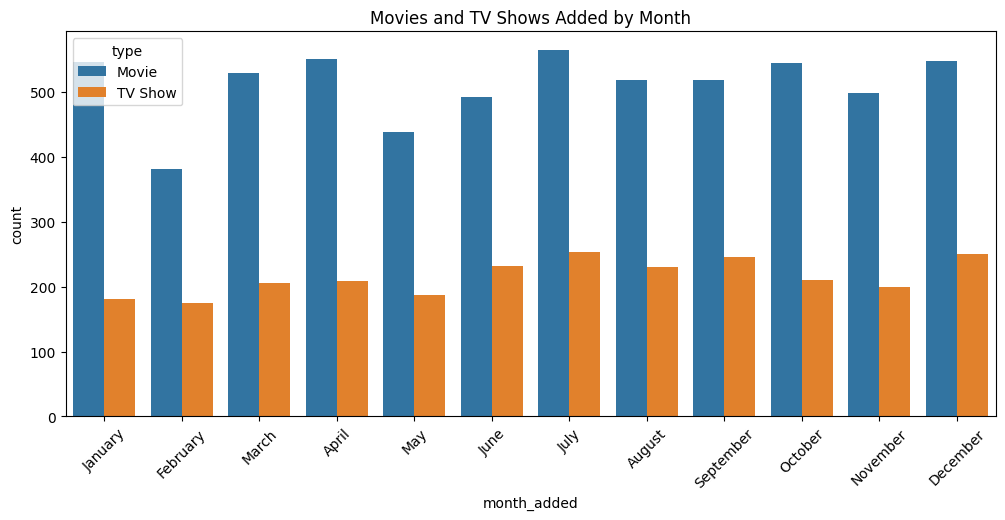

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=month_type,
    x='month_added',
    y='count',
    hue='type'
)

plt.title('Movies and TV Shows Added by Month')
plt.xticks(rotation=45)

plt.show()

**Observation**

The monthly distribution of content additions was analyzed separately for Movies and TV Shows and visualized together for comparison. Movies consistently outnumber TV Shows across all months.

For Movies, the highest number of additions occurred in July, followed closely by December and April. For TV Shows, the highest number of additions occurred in July and December. February recorded the lowest number of additions for both content types.

The results indicate that Netflix tends to increase content additions during the middle and end of the year, particularly in July and December, which may coincide with periods of higher audience engagement and viewing activity.

## Best Week to Launch Content

The weekly distribution of content additions is analyzed to identify the most active release periods for Movies and TV Shows.

In [ ]:
df['week_added'] = df['date_added'].dt.isocalendar().week

week_type = (
    df.groupby(['week_added', 'type'])
      .size()
      .reset_index(name='count')
)

week_type.head()

,week_added,type,count
0,1,Movie,316
1,1,TV Show,52
2,2,Movie,78
3,2,TV Show,26
4,3,Movie,81


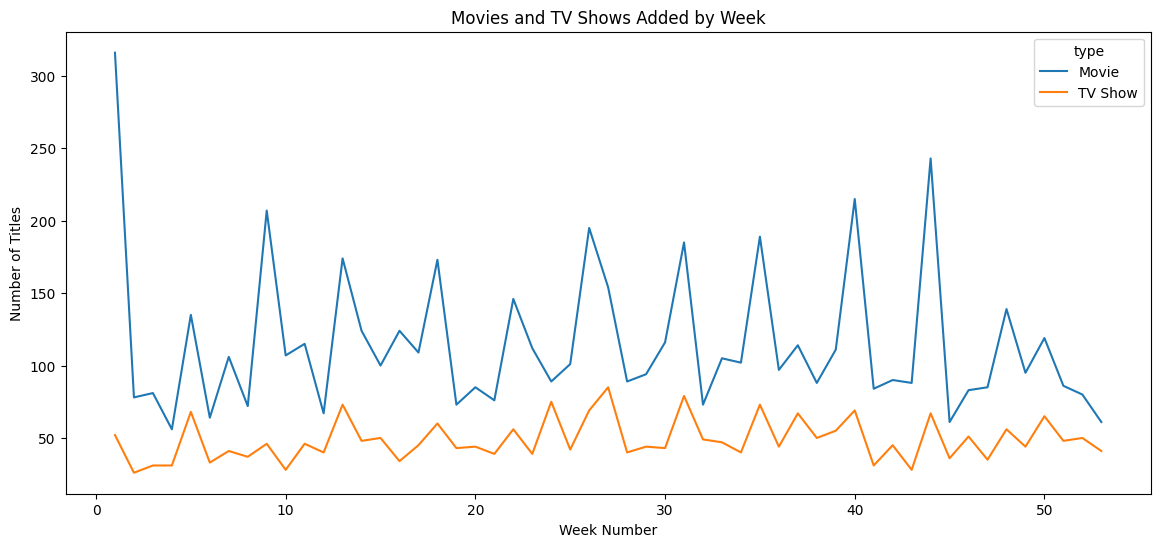

In [ ]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=week_type,
    x='week_added',
    y='count',
    hue='type'
)

plt.title('Movies and TV Shows Added by Week')
plt.xlabel('Week Number')
plt.ylabel('Number of Titles')

plt.show()

In [ ]:
movie_week = (
    df[df['type'] == 'Movie']
    ['week_added']
    .value_counts()
    .head(1)
)

movie_week

,count
week_added,
1,316


In [ ]:
tv_week = (
    df[df['type'] == 'TV Show']
    ['week_added']
    .value_counts()
    .head(1)
)

tv_week

,count
week_added,
27,85


**Observation**

Week 1 recorded the highest number of Movie additions, with 316 titles added during that week. For TV Shows, Week 27 recorded the highest number of additions, with 85 titles added.

This indicates that Netflix does not necessarily follow the same release schedule for Movies and TV Shows. Different content types appear to have different peak release periods throughout the year.

## Top 10 Actors

The most frequently appearing actors are identified to understand which actors contribute most to Netflix's content library.

In [ ]:
top_actors = (
    cast_df[cast_df['cast'] != 'Unknown Actor']
    ['cast']
    .value_counts()
    .head(10)
)

top_actors

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


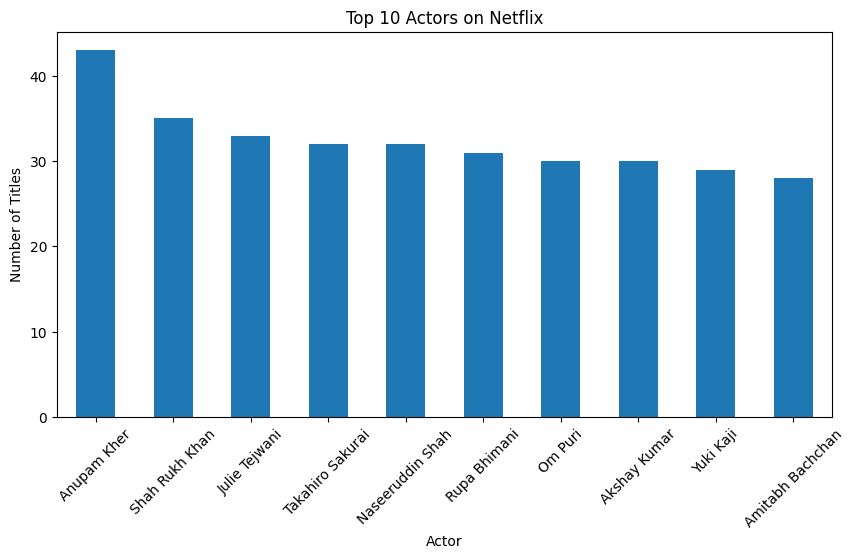

In [ ]:
plt.figure(figsize=(10,5))

top_actors.plot(kind='bar')

plt.title('Top 10 Actors on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

**Observation**

Anupam Kher appears in the highest number of Netflix titles (43), followed by Shah Rukh Khan (35) and Julie Tejwani (33). Several Indian actors feature prominently among the most frequently appearing actors, indicating a strong representation of Indian content within Netflix's catalog.

The relatively small difference between the top actors suggests that Netflix's content library is distributed across a diverse group of performers rather than being dominated by a single actor.

## Top 10 Directors

The most frequently appearing directors are identified to understand which directors contribute most to Netflix's content library.

In [ ]:
top_directors = (
    director_df[director_df['director'] != 'Unknown Director']
    ['director']
    .value_counts()
    .head(10)
)

top_directors

,count
director,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


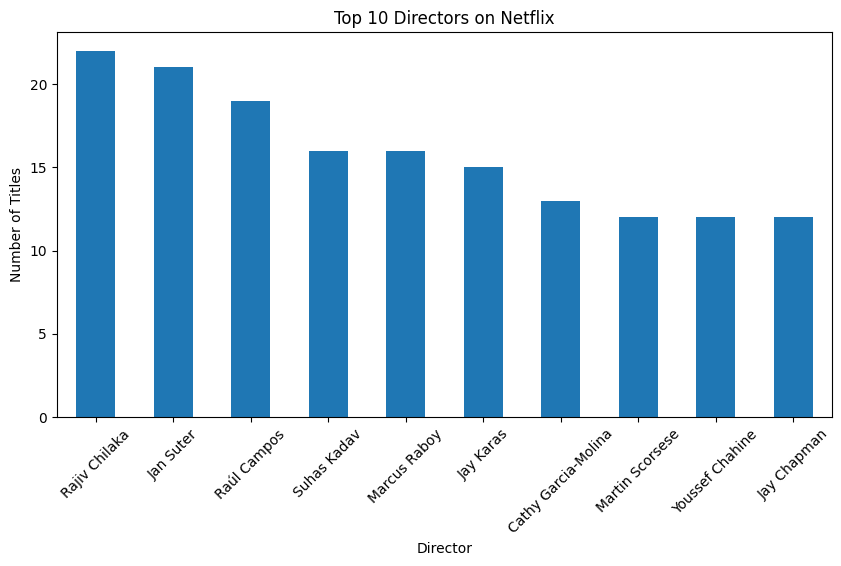

In [ ]:
plt.figure(figsize=(10,5))

top_directors.plot(kind='bar')

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

**Observation**

Rajiv Chilaka is the most frequently appearing director on Netflix with 22 titles, followed closely by Jan Suter (21) and Raúl Campos (19). The distribution among the top directors is relatively balanced, with no single director dominating the platform's content library.

The presence of multiple directors with comparable title counts suggests that Netflix collaborates with a diverse set of creative professionals across different content categories and regions.

## Genre Analysis

The genre distribution is analyzed to identify the most common content categories available on Netflix.

In [ ]:
top_genres = (
    genre_df['listed_in']
    .value_counts()
    .head(10)
)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


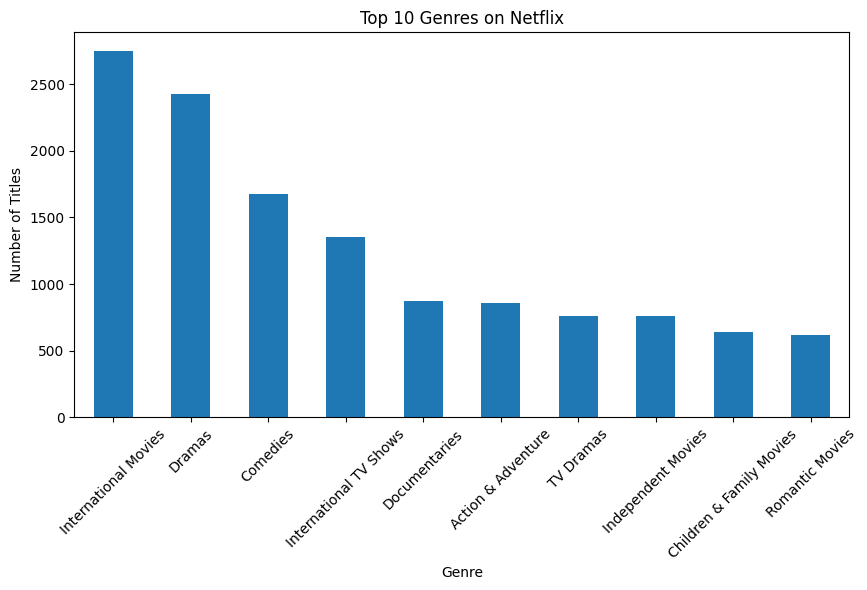

In [ ]:
plt.figure(figsize=(10,5))

top_genres.plot(kind='bar')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.show()

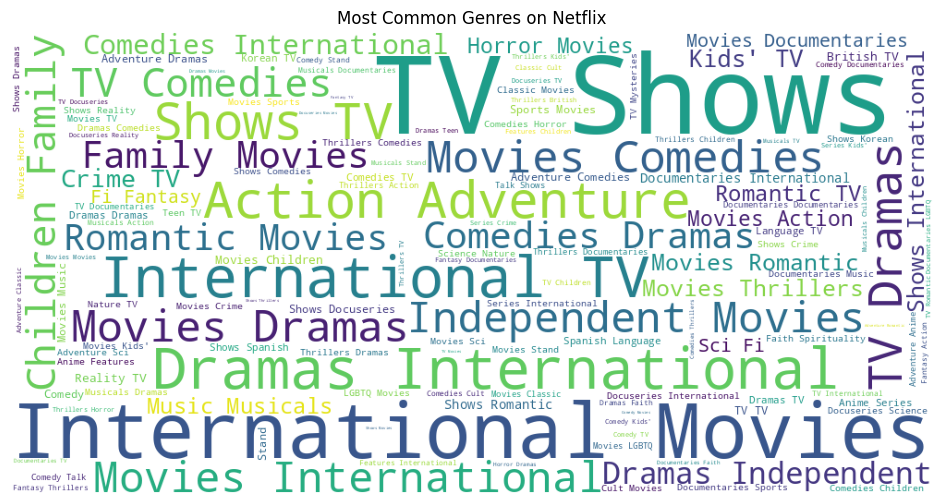

In [ ]:
from wordcloud import WordCloud

genre_text = ' '.join(genre_df['listed_in'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(genre_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Most Common Genres on Netflix')

plt.show()

**Observation**

International Movies is the most common genre on Netflix with 2,752 titles, followed by Dramas (2,427) and Comedies (1,674). International TV Shows also have a strong presence with 1,351 titles.

The genre distribution indicates that Netflix maintains a highly diverse catalog, with significant representation from international content, drama, comedy, documentaries, action & adventure, and family-oriented programming.

The WordCloud further confirms that International Movies, Dramas, Comedies, and TV Shows are the dominant content categories on the platform.

## Time Taken for Content to be Added to Netflix

The difference between the content's release year and the year it was added to Netflix is analyzed to understand how quickly content becomes available on the platform after its release.

This analysis helps identify typical content acquisition timelines and provides insights into Netflix's content distribution strategy.

In [ ]:
df['year_added'] = df['date_added'].dt.year
df[['date_added', 'release_year', 'year_added']].head()

,date_added,release_year,year_added
0,2021-09-25,2020,2021.0
1,2021-09-24,2021,2021.0
2,2021-09-24,2021,2021.0
3,2021-09-24,2021,2021.0
4,2021-09-24,2021,2021.0


In [ ]:
df['years_to_add'] = df['year_added'] - df['release_year']
df[['release_year', 'year_added', 'years_to_add']].head()

,release_year,year_added,years_to_add
0,2020,2021.0,1.0
1,2021,2021.0,0.0
2,2021,2021.0,0.0
3,2021,2021.0,0.0
4,2021,2021.0,0.0


**Creating Content Addition Lag**

A new variable called years_to_add is created to measure the number of years between a title's release and the year it was added to Netflix.

A value of:
- 0 indicates the content was added in the same year it was released.
- 1 indicates the content was added one year after release.
- Higher values indicate longer delays before appearing on Netflix.

In [ ]:
df['years_to_add'].value_counts().head(15)

,count
years_to_add,
0.0,3222
1.0,1559
2.0,707
3.0,484
4.0,358
5.0,260
6.0,247
7.0,183
8.0,183


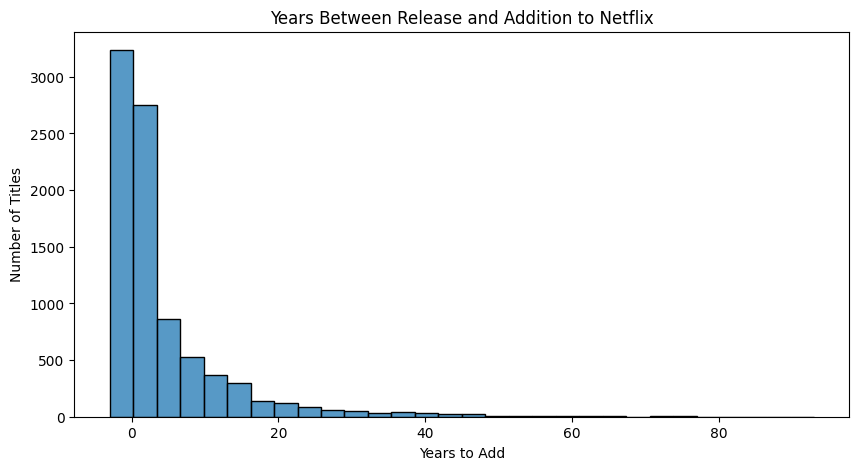

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['years_to_add'],
    bins=30
)

plt.title('Years Between Release and Addition to Netflix')
plt.xlabel('Years to Add')
plt.ylabel('Number of Titles')

plt.show()

**Observation**

The distribution of years_to_add is heavily concentrated near 0, indicating that most content is added to Netflix shortly after its release. The most frequent value is 0 years, with 3,222 titles being added during the same year they were released.

The frequency of content additions decreases steadily as the gap between release and Netflix addition increases. Only a small number of titles were added after long delays, resulting in a right-skewed distribution with a long tail.

This pattern suggests that Netflix generally prioritizes recent content and aims to make titles available to viewers as quickly as possible after release.

## Business Insights

1. **Movies continue to dominate Netflix's content library**, accounting for a much larger share of the catalog than TV Shows. However, the sizeable TV Show catalog indicates that Netflix recognizes the growing importance of serialized content in driving long-term viewer engagement.

2. **The United States remains Netflix's strongest content market**, contributing the largest number of movies and TV shows. At the same time, India's position as the second-largest movie contributor highlights its growing importance as both a content production hub and a consumer market.

3. **Asian markets play a major role in Netflix's TV Show ecosystem**, particularly Japan and South Korea. The strong representation of content from these countries reflects the global popularity of Asian television content and Netflix's success in expanding beyond Western markets.

4. **Netflix has significantly increased content production and acquisition over the last decade**, with especially rapid growth in TV Shows after 2015. This suggests a deliberate shift toward binge-worthy and long-form content that helps keep subscribers engaged for longer periods.

5. **Content additions are not evenly distributed throughout the year.** Netflix appears to concentrate releases during July and December, indicating that these periods are strategically important for maximizing audience engagement and platform activity.

6. **Movies and TV Shows follow different release cycles.** While movie additions peak at the beginning of the year, TV Shows see their highest activity around the middle of the year, suggesting that Netflix tailors release schedules based on content type and audience consumption patterns.

7. **India's influence extends beyond content volume and is also reflected in talent representation.** Several of the most frequently appearing actors in the dataset are from the Indian entertainment industry, further emphasizing the market's importance to Netflix.

8. **Netflix's content catalog is built through collaborations with a diverse group of directors rather than a handful of dominant creators.** This diversified approach reduces creative dependency and helps maintain variety across genres and regions.

9. **International content has become one of Netflix's biggest strengths.** International Movies and International TV Shows are among the platform's most common categories, demonstrating Netflix's ability to attract audiences through globally diverse content offerings.

10. **Netflix prioritizes recent content acquisition.** A large proportion of titles are added during the same year they are released, showing the platform's focus on keeping its catalog fresh and relevant for viewers.

## Recommendations

1. **Align major content launches with historical peak activity periods.** Since July and December consistently show the highest content additions, Netflix should prioritize flagship releases, original productions, and high-profile marketing campaigns during these months to maximize audience engagement.

2. **Adopt content-type-specific release strategies.** The analysis shows that Movies and TV Shows follow different release patterns. Netflix can improve visibility and audience reach by scheduling movie releases during historically strong early-year periods and concentrating major TV Show launches around mid-year peaks.

3. **Strengthen investments in key international markets, particularly India.** Given India's strong contribution to both content volume and talent representation, expanding regional content production and partnerships can help drive subscriber growth and engagement in one of Netflix's most important markets.

4. **Maintain long-term partnerships with successful actors and directors while nurturing new talent.** A balanced talent strategy can help Netflix preserve content quality, encourage innovation, and reduce dependence on a limited group of creators.

5. **Continue expanding international and localized content offerings.** The strong presence of International Movies and International TV Shows demonstrates global demand for region-specific content. Netflix should further invest in localization, dubbing, subtitling, and regional productions to strengthen its global appeal.

6. **Sustain investment in high-performing genres while diversifying the content portfolio.** Drama and Comedy remain core content categories and should continue receiving significant investment. At the same time, Netflix should explore opportunities in less represented genres to attract niche audiences and reduce content saturation.

7. **Prioritize rapid content acquisition and distribution.** Since most titles are added during the same year they are released, Netflix should continue minimizing the gap between release and platform availability. Faster content availability can improve viewer satisfaction, strengthen competitiveness, and support subscriber retention.